# Scenario Comparison Analysis

In [18]:
import json
import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import os

In [19]:
home = "/home/lucakristin/Desktop/my_pypsa"
base_folder = "germany_base_"
cluster = "450" 

### Create scenario network 

In [23]:
wind_conditions = ["windy", "notwindy", "windvariability"]
capacity_scenarios = ["germany_scenario1", "germany_scenario2"]

!python ../create_germany_scenario.py \
    --home {home} \
    --base-folder {base_folder} \
    --cluster {cluster} \
    --wind-condition {" ".join(wind_conditions)} \
    --capacity-scenario {" ".join(capacity_scenarios)}

[Wed May  6 10:36:04 2026] Processing scenario: germany_scenario1 with wind condition: windy
[Wed May  6 10:36:04 2026] Loading base network from: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/results/germany_base_windy/networks/base_s_450_elec_.nc
INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, storage_units, stores, sub_networks
[Wed May  6 10:36:06 2026] Loading scenario configuration from: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/config/scenario_configs/germany_scenario1.json
/home/lucakristin/Desktop/my_pypsa/pypsa-eur/notebooks/../create_germany_scenario.py:217: DeprecatedWarning: iterate_components is deprecated as of 1.0.0 and will be removed in 2.0.0. Use `for component in n.components` instead.
  for component in n.iterate_components(["Line", "Link"]):
/home/lucakristin/Desktop/my_pypsa/pypsa-eur/notebooks/../create_germany_scenario.py:218: Dep

In [24]:
def get_capacity_percentages(network):
    """Calculates the capacity share by carrier for a given network."""
    carrier_capacity = network.generators.groupby("carrier").p_nom.sum()
    carrier_capacity_pct = 100 * carrier_capacity / carrier_capacity.sum()
    return carrier_capacity_pct.round(2)

def load_networks(home, base_folder, cluster, wind_opt, scenario_name):
    """Loads the base and scenario networks."""
    base_config_name = f"{base_folder}{wind_opt}"
    scenario_config_name = f"{scenario_name}_{wind_opt}"
    
    base_network_path_unsolved = f"{home}/pypsa-eur/results/{base_config_name}/networks/base_s_{cluster}_elec_.nc"
    n_base_unsolved = pypsa.Network(base_network_path_unsolved)
    
    scenario_network_path_unsolved = f"{home}/pypsa-eur/resources/{scenario_config_name}/networks/base_s_{cluster}_elec_.nc"
    n_scenario_unsolved = pypsa.Network(scenario_network_path_unsolved)
    
    return n_base_unsolved, n_scenario_unsolved, base_config_name, scenario_config_name

def plot_capacity_comparison(ax, n_base, n_scenario, base_name, scenario_name):
    """Plots the initial installed capacity comparison on a given axes."""
    p_nom_base = n_base.generators.groupby("carrier").p_nom.sum()
    p_nom_scenario = n_scenario.generators.groupby("carrier").p_nom.sum()

    df = pd.DataFrame({
        "Base": p_nom_base,
        "Scenario": p_nom_scenario
    }).dropna()

    df.plot(kind="bar", ax=ax, rot=45)
    ax.set_ylabel("Installed Capacity [MW]")
    ax.set_title(f"Base: {base_name} vs Scenario: {scenario_name}")
    ax.grid(True)

INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.2)


Capacity share by carrier (% of total installed generator capacity):
               Base (germany_base_windy)  Scenario (germany_scenario1_windy)
carrier                                                                     
onwind                             31.77                               40.86
solar                              21.13                               26.88
CCGT                               13.33                                3.23
coal                                8.82                                1.08
lignite                             8.43                                0.21
offwind-ac                          4.84                               19.35
biomass                             3.47                                3.62
OCGT                                2.65                                1.08
oil                                 2.46                                1.08
ror                                 1.74                                1.15
waste  

INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, storage_units, stores, sub_networks


Capacity share by carrier (% of total installed generator capacity):
               Base (germany_base_windy)  Scenario (germany_scenario2_windy)
carrier                                                                     
onwind                             31.77                               39.17
solar                              21.13                               27.83
CCGT                               13.33                                8.25
coal                                8.82                                2.06
lignite                             8.43                                2.06
offwind-ac                          4.84                               10.31
biomass                             3.47                                5.15
OCGT                                2.65                                1.03
oil                                 2.46                                1.03
ror                                 1.74                                1.03
waste  

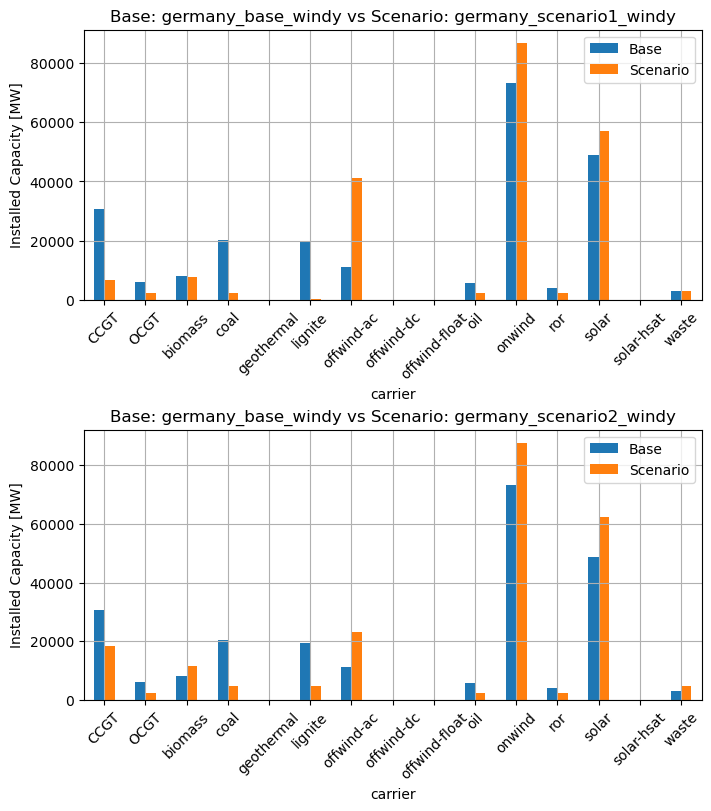

In [25]:
# Create a figure with subplots
num_scenarios = len(capacity_scenarios)
fig, axes = plt.subplots(num_scenarios, 1, figsize=(7, 4 * num_scenarios), constrained_layout=True)

wind_opt = "windy"  # or "not-windy" or "wind-variability"
for j, scenario_name in enumerate(capacity_scenarios):
    ax = axes[j]
    n_base, n_scenario, base_name, scenario_name_full = load_networks(home, base_folder, cluster, wind_opt, scenario_name)
    plot_capacity_comparison(ax, n_base, n_scenario, base_name, scenario_name_full)

    # Get percentages for both scenarios
    base_percentages = get_capacity_percentages(n_base)
    scenario_percentages = get_capacity_percentages(n_scenario)

    # Combine into a single DataFrame for side-by-side comparison
    comparison_df = pd.DataFrame({
        f"Base ({base_name})": base_percentages,
        f"Scenario ({scenario_name_full})": scenario_percentages
    })

    # Sort by the base percentages in descending order
    comparison_df = comparison_df.sort_values(by=f"Base ({base_name})", ascending=False)

    # Display the comparison
    print("Capacity share by carrier (% of total installed generator capacity):")
    print(comparison_df.fillna("-").to_string())

plt.show()

---
# Solving networks

## 1. Check if config.yaml exists before solving 

In [26]:
# Check that a matching scenario config file exists before creating the network.
scenario_yaml_path = f"{home}/pypsa-eur/config/config.{scenario_name_full}.yaml"
if not os.path.isfile(scenario_yaml_path):
    raise FileNotFoundError(
        f"Missing scenario config file: {scenario_yaml_path}\n"
        f"Expected a file named config.{scenario_name_full}.yaml in pypsa-eur/config/."
    )
print(f"Found scenario config: {scenario_yaml_path}")

Found scenario config: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/config/config.germany_scenario2_windy.yaml


## 2. Solve the network -> for line loads
```bash
snakemake -n -call solve_elec_networks --configfile config/config.germany_scenario.yaml
```

#### Unlock command

```bash
cd pypsa-eur && conda activate pypsa-eur && snakemake -call solve_elec_networks --configfile config/config.germany_scenario_1.yaml --unlock
```

```
Using workflow specific profile profiles/default for setting default command line arguments.
Config file config/config.default.yaml is extended by additional config specified via the command line.
Config file config/plotting.default.yaml is extended by additional config specified via the command line.
Unlocked working directory.
```

## 3. Load solved networks

In [ ]:
# --- Load Base Network ---
base_network_path = f"{home}/pypsa-eur/results/{base_name}/networks/base_s_{cluster}_elec_.nc"
n_base = pypsa.Network(base_network_path, name="Base Network")
n_base.name = "Base Network"

# --- Load Scenario Network ---
scenario_network_path = f"{home}/pypsa-eur/results/{scenario_name_full}/networks/base_s_{cluster}_elec_.nc"
n_scenario = pypsa.Network(scenario_network_path, name="Scenario Network")
n_scenario.name = "Scenario Network"

INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, stores, sub_networks
